In [ ]:
# 0. 라이브러리 import
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics ixmport accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
# ! pip install catboost
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

# !pip install -q xgboost lightgbm

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay


In [2]:
# 1. 데이터 불러오기
titanic_df = sns.load_dataset('titanic')

titanic_df.info()
titanic_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# 2. 데이터 / 메타 정보 확인


titanic_df.describe()
titanic_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
titanic_df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [5]:
# 3, 타겟 정의 + 분석
titanic_df['survived'].value_counts()/ titanic_df.shape[0] # 비율 확인

survived
0    0.616162
1    0.383838
Name: count, dtype: float64

In [6]:
# 4. 학습 / 검증 데이터 분리 - eda 전에 꼭 하기
train, test = train_test_split(
    titanic_df, stratify=titanic_df['survived'], random_state=42,test_size=0.3
)
# 분류 문제라면 stratify를 사용해서 class 비율을 유지
train.shape, test.shape

((623, 15), (268, 15))

survived,0,1
sex,,
female,0.257962,0.742038
male,0.811092,0.188908


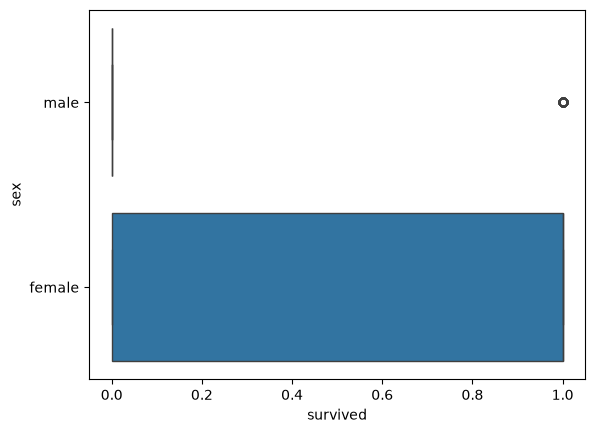

In [7]:
# 5. EDA - Target vs Features
sns.boxplot(
    data=titanic_df,
    x=titanic_df['survived'],
    y="sex"
)

pd.crosstab(
    titanic_df["sex"],
    titanic_df['survived'],
    normalize="index"
)

<Axes: >

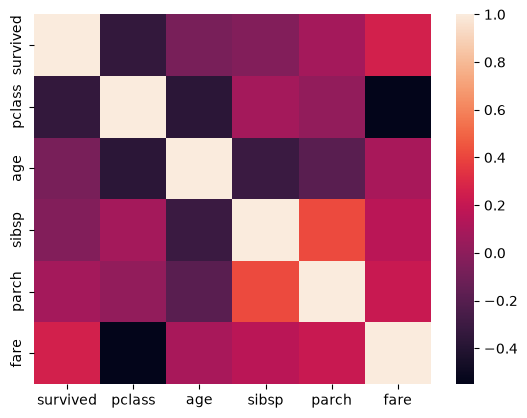

In [8]:
# 5. EDA - Features vs Features

corr = titanic_df.select_dtypes("number").corr()

sns.heatmap(corr)

In [9]:

# 6. data cleaning ( 데이터 전처리 )


# 6-1. row 중복 제거
print(f"before: {train.shape}")

# 평가는 학습을 하는 데이터가 아니기 때문에 row 중복 제거 제외
train.drop_duplicates(inplace=True)
print(f"after: {train.shape}")

before: (623, 15)
after: (564, 15)


In [10]:
age_mean = train["age"].mean()

train["age"] = train["age"].fillna(age_mean)
test["age"] = test["age"].fillna(age_mean)

In [11]:
# 6-2. 결측치 확인 및 제거
null_tr = train.isnull().sum()

(null_tr[null_tr > 0] / train.shape[0]).sort_values(ascending=False)

deck           0.760638
embarked       0.003546
embark_town    0.003546
dtype: float64

In [12]:
print(f"before: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

for tmp in [train, test]:
    null_tmp = tmp.isnull().sum()
    null_cols = null_tmp[null_tmp > 0].index

    for col in null_cols:
        try:
            tmp[col] = tmp[col].fillna(train[col].mean())

        except:
            tmp[col] = tmp[col].fillna(train[col].mode().values[0])

print(f"after: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

before: 433 / 200
after: 0 / 0


In [13]:
# 6-3. Feature 생성

train["family_size"] = (
    train["sibsp"]
    + train["parch"]
    + 1
)

test["family_size"] = (
    test["sibsp"]
    + test["parch"]
    + 1
)



In [14]:
for frame in [train, test]:
    frame["FamilySize"] = (
        frame["sibsp"]
        + frame["parch"]
        + 1
    )

    frame["IsAlone"] = (
        frame["FamilySize"] == 1
    ).astype(int)

    frame["FamilyGroup"] = pd.cut(
        frame["FamilySize"],
        bins=[0, 1, 4, np.inf],
        labels=["Alone", "Small", "Large"]
    ).astype(str)

In [15]:
for frame in [train, test]:
    frame["Sex_Pclass"] = (
        frame["sex"].astype(str)
        + "_"
        + frame["pclass"].astype(str)
    )

In [16]:
for frame in [train, test]:
    frame["WomanChild"] = (
        (frame["sex"] == "female")
        | (frame["age"] < 16)
    ).astype(int)

In [17]:
for frame in [train, test]:
    frame["adult_male"] = (
        frame["adult_male"]
        .astype(int)
    )

    frame["who"] = (
        frame["who"]
        .astype(str)
    )

In [18]:
for frame in [train, test]:
    frame["Child_Pclass"] = (
        (frame["age"] < 16).astype(int).astype(str)
        + "_"
        + frame["pclass"].astype(str)
    )

In [19]:
# 새로만들 피처들과 기존 피처들 비교해서 유사한 피처 제거 - > 오버피팅 대표적인 원인  이때 차원축소를 사용
# 군집화는 타겟 X 분류 학습 - 비지도 학습 , 차원 축소는 pca 피처 자체를 줄일 때 사용

In [31]:
# 6-4. 불필요한 컬럼 삭제
# train.drop(['alive', 'who', 'adult_male', 'embark_town', 'alone', 'pclass','deck'], axis=1, inplace=True)
# test.drop(['alive', 'who', 'adult_male', 'embark_town', 'alone', 'pclass','deck'], axis=1, inplace=True)
train.drop(['alive','adult_male'], axis=1, inplace=True)
test.drop(['alive','adult_male'], axis=1, inplace=True)

titanic_df.shape

KeyError: "['alive', 'adult_male'] not found in axis"

In [21]:
# 6-5. 인코딩 (LightGBM은 조금 다름)

# x_tr[cat_cols] = x_tr[cat_cols].astype("category")
# x_te[cat_cols] = x_te[cat_cols].astype("category")

In [22]:
# 6-6. Scaling
from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# scaler.fit(train[num_cols])

# X_train[num_cols] = scaler.transform(X_train[num_cols])
# X_valid[num_cols] = scaler.transform(X_valid[num_cols])
# test[num_cols] = scaler.transform(test[num_cols])

#LightGBM 예제 : 별도의 Scaling 단계는 없음 !!

In [23]:
# 7. 모델링 전 확인 ! - 전처리 검증

assert train.isnull().sum().sum() == 0, "결측치가 존재합니다."
assert test.isnull().sum().sum() == 0, "결측치가 존재합니다."

assert train.shape[1] == test.shape[1], "컬럼 수가 다릅니다."

In [24]:
# 8. X / y 분리
x_tr = train.drop(['survived'], axis=1)
y_tr = train['survived']
x_te = test.drop(['survived'], axis=1)
y_te = test['survived']

x_tr.shape, y_tr.shape, x_te.shape, y_te.shape

((564, 19), (564,), (268, 19), (268,))

In [ ]:
# 9. 모델 학습 시작

In [33]:
cat_cols = x_tr.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

In [37]:
hp = {
    "random_state" : 42,
    "verbose" : 0, # 부스팅 단계 출력 안보이게 하기
    "iterations":800,
    "learning_rate":0.03,
    "depth":5,
    "l2_leaf_reg":5,
    "border_count":64,
    "loss_function":"Logloss",
    "eval_metric":"AUC",
    "task_type":"CPU",
    "class_weights" :[1.0, 3.0]

}


cat = CatBoostClassifier(**hp).fit(x_tr, y_tr, cat_features=cat_cols)
print(f'훈련용 평가지표: {cat.score(x_tr, y_tr)} / 테스트용 평가지표: {cat.score(x_te, y_te)}')


훈련용 평가지표: 0.8173758865248227 / 테스트용 평가지표: 0.8022388059701493


In [38]:

print(f'훈련용 평가지표: {cat.score(x_tr, y_tr)} / 테스트용 평가지표: {cat.score(x_te, y_te)}')

훈련용 평가지표: 0.8173758865248227 / 테스트용 평가지표: 0.8022388059701493


In [39]:
# 10. 모델 평가
from sklearn.metrics import recall_score

# 훈련용 feature를 이용해서 target 예측
y_pre_tr = cat.predict(x_tr)
# target 예측(y_pre_tr)와 실제 데이터(y_tr)를 이용한 점수!
train_score = recall_score(y_tr, y_pre_tr)

# 평가용 feature를 이용해서 target 예측
y_pre_te = cat.predict(x_te)
# target 예측(y_pre_te)와 실제 데이터(y_te)를 이용한 점수!
test_score = recall_score(y_te, y_pre_te)

print(f'훈련용 평가지표: {train_score} / 테스트용 평가지표: {test_score}')

훈련용 평가지표: 0.8701298701298701 / 테스트용 평가지표: 0.8737864077669902


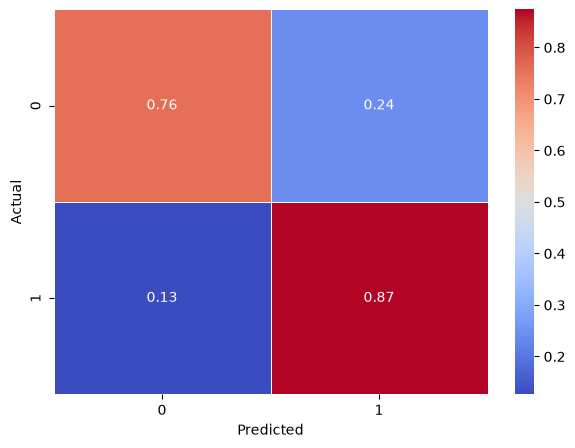

In [40]:
# 11. 오답 분석
from sklearn.metrics import confusion_matrix

norm_conf_mx = confusion_matrix(y_te, y_pre_te, normalize="true")

plt.figure(figsize=(7,5))

sns.heatmap(norm_conf_mx, annot=True, cmap="coolwarm", linewidth=0.5)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [41]:
# 12. 모델 평가 - AUC

from sklearn.metrics import roc_auc_score

# train 데이터의 생존(1) 확률
y_proba_tr = cat.predict_proba(x_tr)[:, 1]

# test 데이터의 생존(1) 확률
y_proba_te = cat.predict_proba(x_te)[:, 1]

# AUC 계산
train_score = roc_auc_score(y_tr, y_proba_tr)
test_score = roc_auc_score(y_te, y_proba_te)

print(
    f'훈련용 AUC: {train_score:.4f} / '
    f'테스트용 AUC: {test_score:.4f}'
)

훈련용 AUC: 0.9227 / 테스트용 AUC: 0.8796


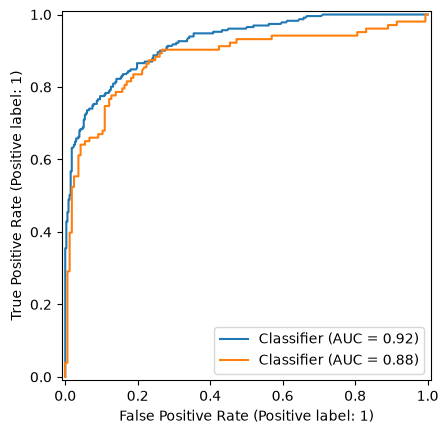

In [42]:
# 12. 모델 평가 - AUC 그래프 그리기
from sklearn.metrics import RocCurveDisplay

fig,ax = plt.subplots()
RocCurveDisplay.from_predictions(y_tr,y_proba_tr,ax=ax)
RocCurveDisplay.from_predictions(y_te,y_proba_te,ax=ax)
plt.show()

In [ ]:
# xGBoost / Light GBM / Catboost  AUC 비교 !

In [ ]:
# CatBoost는 범주형 데이터를 직접 처리할 수 있지만,
# XGBoost / LightGBM 비교를 위해 원-핫 인코딩 데이터를 따로 생성

In [43]:
# 13-1. XGBoost / LightGBM용 범주형 데이터 인코딩


# 인코딩 추가
cat_cols = x_tr.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

x_tr_encoded = pd.get_dummies(x_tr, columns=cat_cols, drop_first=False)
x_te_encoded = pd.get_dummies(x_te, columns=cat_cols, drop_first=False)

# train에 존재하는 컬럼 기준으로 test 컬럼 맞추기
# test에 없는 범주는 0으로 채움 !!
x_te_encoded = x_te_encoded.reindex(columns=x_tr_encoded.columns, fill_value=0)

print('원본:', x_tr.shape, x_te.shape)
print('인코딩 후:', x_tr_encoded.shape, x_te_encoded.shape)


원본: (564, 19) (268, 19)
인코딩 후: (564, 47) (268, 47)


C:\Users\Playdata\AppData\Local\Temp\ipykernel_7896\4035234627.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x_tr.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


In [44]:
# 13-2. 세 모델 학습 + AUC 계산

# 1) XGBoost
xgb = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    random_state=134,
    eval_metric='auc',
    scale_pos_weight=3,
    n_jobs=-1
)
xgb.fit(x_tr_encoded, y_tr)

# 2) LightGBM
lgbm = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    random_state=134,
    class_weight={0: 1.0, 1: 3.0},
    verbosity=-1,
    n_jobs=-1
)
lgbm.fit(x_tr_encoded, y_tr)

# 3) CatBoost
# 위에서 이미 학습한 cat 모델을 그대로 사용

# 각 모델의 '생존(1)' 확률 추출
xgb_proba_tr = xgb.predict_proba(x_tr_encoded)[:, 1]
xgb_proba_te = xgb.predict_proba(x_te_encoded)[:, 1]

lgbm_proba_tr = lgbm.predict_proba(x_tr_encoded)[:, 1]
lgbm_proba_te = lgbm.predict_proba(x_te_encoded)[:, 1]

cat_proba_tr = cat.predict_proba(x_tr)[:, 1]
cat_proba_te = cat.predict_proba(x_te)[:, 1]

# AUC 계산 ㄱㄱ
auc_result = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'Train AUC': [
        roc_auc_score(y_tr, xgb_proba_tr),
        roc_auc_score(y_tr, lgbm_proba_tr),
        roc_auc_score(y_tr, cat_proba_tr)
    ],
    'Test AUC': [
        roc_auc_score(y_te, xgb_proba_te),
        roc_auc_score(y_te, lgbm_proba_te),
        roc_auc_score(y_te, cat_proba_te)
    ]
})

auc_result = auc_result.sort_values('Test AUC', ascending=False).reset_index(drop=True)
auc_result


,Model,Train AUC,Test AUC
0,CatBoost,0.922721,0.879582
1,LightGBM,0.991290,0.838776
2,XGBoost,0.997094,0.835422


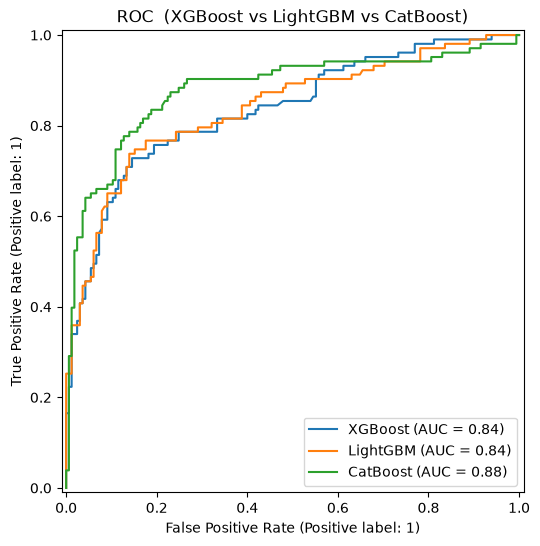

In [45]:
# 13-3. 세 모델 ROC Curve 비교
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_te, xgb_proba_te, name='XGBoost', ax=ax)
RocCurveDisplay.from_predictions(y_te, lgbm_proba_te, name='LightGBM', ax=ax)
RocCurveDisplay.from_predictions(y_te, cat_proba_te, name='CatBoost', ax=ax)

plt.title('ROC  (XGBoost vs LightGBM vs CatBoost)')
plt.show()


In [49]:
x_tr.columns

Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class',
       'who', 'deck', 'embark_town', 'alone', 'family_size', 'FamilySize',
       'IsAlone', 'FamilyGroup', 'Sex_Pclass', 'WomanChild', 'Child_Pclass'],
      dtype='str')